In [1]:
# https://www.geeksforgeeks.org/machine-learning/k-mode-clustering-in-python/

import numpy as np

data = np.array([
    ['A', 'B', 'C'],
    ['B', 'C', 'A'],
    ['C', 'A', 'B'],
    ['A', 'C', 'B'],
    ['A', 'A', 'B']
])

In [2]:
# Set Number of Clusters

k = 2

In [3]:
# Pick Starting Points (Modes)
# Randomly choose k rows from the data to be the starting cluster centers.

np.random.seed(0)
modes = data[np.random.choice(data.shape[0], k, replace=False)]

In [4]:
# Assign Data to Clusters

clusters = np.zeros(data.shape[0], dtype=int)

for _ in range(10):
    for i, point in enumerate(data):
        distances = [np.sum(point != mode) for mode in modes]
        clusters[i] = np.argmin(distances)

In [6]:
import pandas as pd

# Update Cluster Modes

for j in range(k):
        if np.any(clusters == j):
            modes[j] = pd.DataFrame(data[clusters == j]).mode().iloc[0].values

In [7]:
# View Final Results

print("Cluster assignments:", clusters)
print("Cluster modes:", modes)

Cluster assignments: [1 0 0 0 0]
Cluster modes: [['A' 'A' 'B']
 ['A' 'B' 'C']]


The output shows that the first data point belongs to cluster 1 and the rest belong to cluster 0.

Each cluster has a common pattern: cluster 0 has mode values ['A', 'A', 'B'] and cluster 1 has ['A', 'B', 'C'].
These modes represent the most frequent values in each cluster and are used to group similar rows together.

# Cluster with kmodes Library

Elbow method is used to find the optimal number of clusters

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 7.0
Best run was number 1
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 2, cost: 4.0
Run 1, iteration: 2/100, moves: 0, cost: 4.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 1, cost: 4.0
Run 2, iteration: 2/100, moves: 0, cost: 4.0
Init: initial

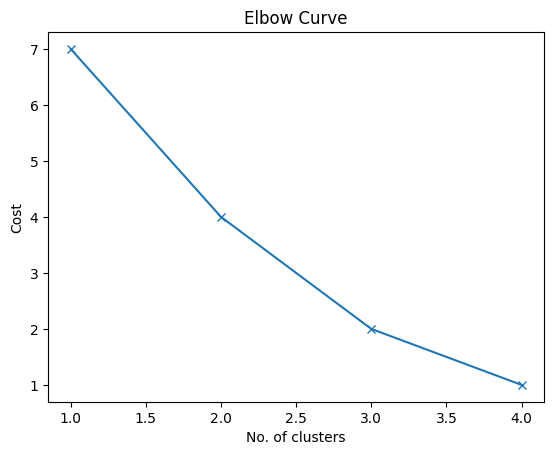

In [8]:
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt

cost = []
K = range(1,5)
for k in list(K):
    kmode = KModes(n_clusters=k, init = "random", n_init = 5, verbose=1)
    kmode.fit_predict(data)
    cost.append(kmode.cost_)

plt.plot(K, cost, 'x-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Curve')
plt.show()

In [9]:
kmode = KModes(n_clusters=2, init = "random", n_init = 5, verbose=1)
clusters = kmode.fit_predict(data)
clusters

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 5.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 1, cost: 4.0
Run 2, iteration: 2/100, moves: 0, cost: 4.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 2, cost: 5.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 5.0
Best run was number 2


array([0, 1, 0, 0, 0], dtype=uint16)

In [10]:
# This also shows that the first, third, fourth and fifth data points have been assigned to the first cluster and the second data points have been assigned to the second cluster.
# To find the best number of groups we use the Elbow Method which helps us see when adding more groups doesn't make a big difference.